In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
df = pd.read_csv('diabetes.csv')

print("Dataset Awal")
display(df.head())

Dataset Awal


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
multiplier = int(np.ceil(1000 / len(df)))

df = pd.concat([df] * multiplier, ignore_index=True)

print("Shape Dataset")
print(df.shape)

Shape Dataset
(1536, 9)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1536 non-null   int64  
 1   Glucose                   1536 non-null   int64  
 2   BloodPressure             1536 non-null   int64  
 3   SkinThickness             1536 non-null   int64  
 4   Insulin                   1536 non-null   int64  
 5   BMI                       1536 non-null   float64
 6   DiabetesPedigreeFunction  1536 non-null   float64
 7   Age                       1536 non-null   int64  
 8   Outcome                   1536 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 108.1 KB
None


In [7]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.368480,31.962202,19.349501,15.947021,115.206457,7.881592,0.331221,11.756400,0.476796
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.368480,31.962202,19.349501,15.947021,115.206457,7.881592,0.331221,11.756400,0.476796
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
np.random.seed(42)

for col in df.columns[:-1]:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

print(df.isnull().sum())

Pregnancies                 77
Glucose                     77
BloodPressure               77
SkinThickness               77
Insulin                     77
BMI                         77
DiabetesPedigreeFunction    77
Age                         77
Outcome                      0
dtype: int64


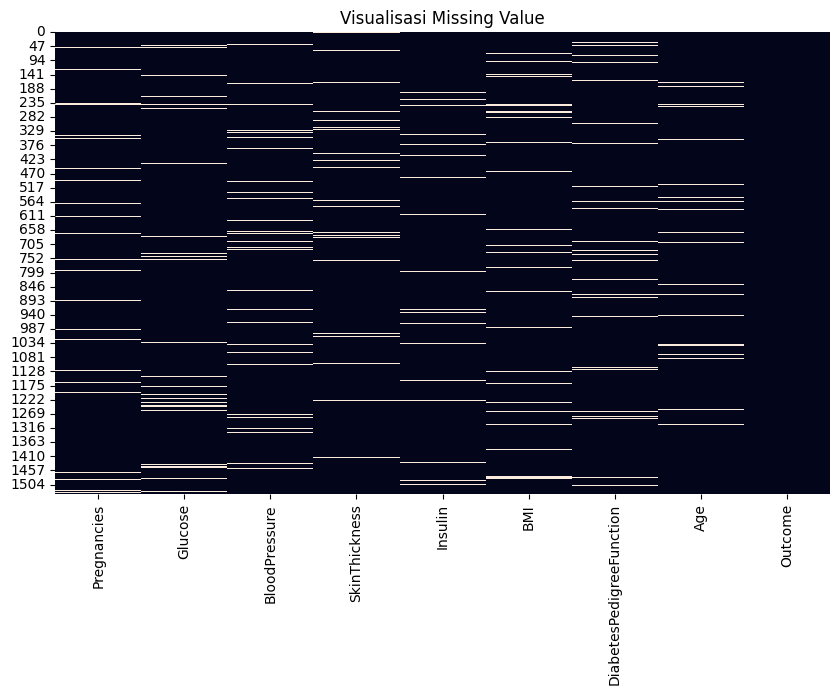

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Visualisasi Missing Value")

plt.show()

In [12]:
mean_imputer = SimpleImputer(strategy='mean')

df_mean = pd.DataFrame(
    mean_imputer.fit_transform(df),
    columns=df.columns
)

In [13]:
median_imputer = SimpleImputer(strategy='median')

df_median = pd.DataFrame(
    median_imputer.fit_transform(df),
    columns=df.columns
)

In [14]:
print(df_median.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


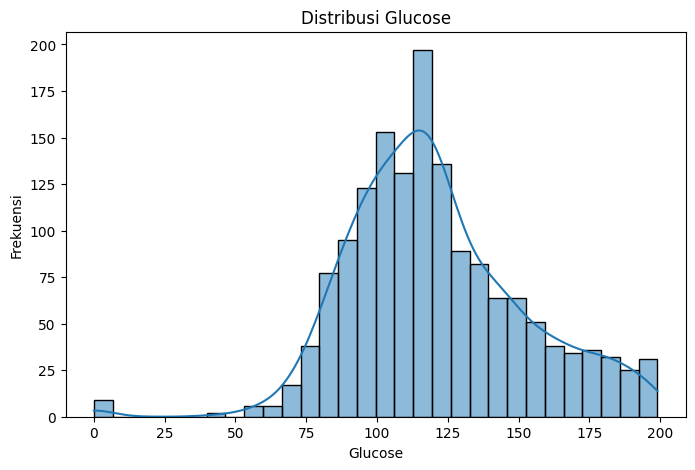

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df_median['Glucose'], kde=True)

plt.title("Distribusi Glucose")

plt.xlabel("Glucose")

plt.ylabel("Frekuensi")

plt.show()

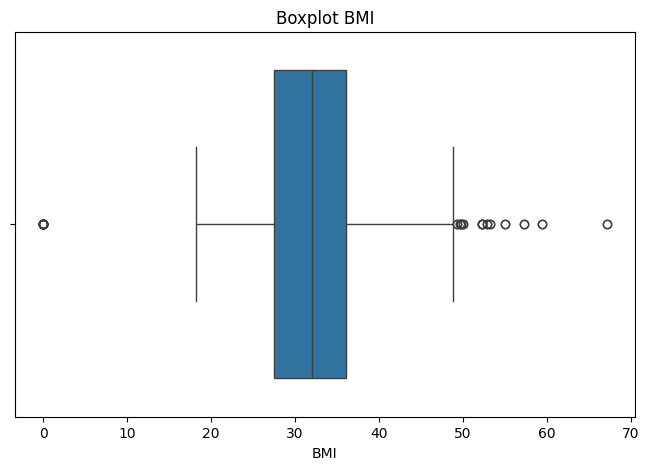

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_median['BMI'])

plt.title("Boxplot BMI")

plt.show()

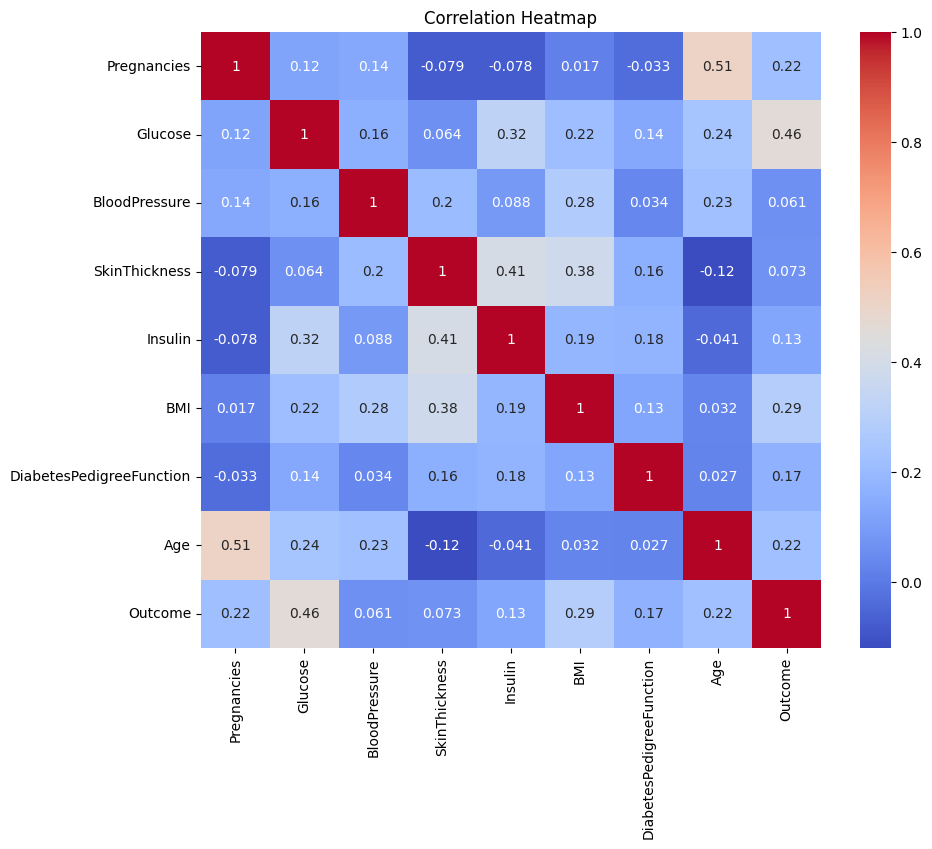

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_median.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
X = df_median.drop('Outcome', axis=1)

y = df_median['Outcome']

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)

print("X_test :", X_test.shape)

X_train : (1228, 8)
X_test : (308, 8)


In [21]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [22]:
model.fit(X_train, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [23]:
y_pred = model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9058441558441559


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93       195
         1.0       0.92      0.81      0.86       113

    accuracy                           0.91       308
   macro avg       0.91      0.89      0.90       308
weighted avg       0.91      0.91      0.90       308



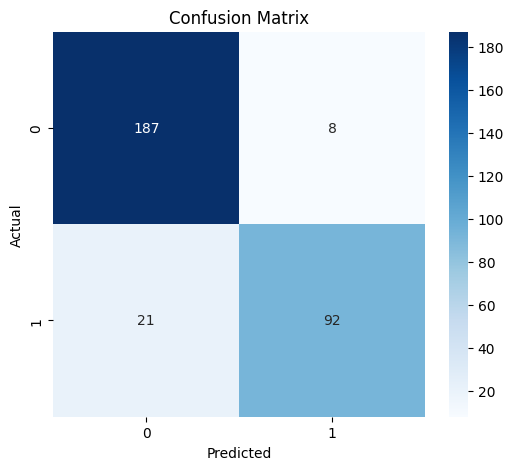

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [27]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Glucose,0.264388
5,BMI,0.156008
7,Age,0.133093
6,DiabetesPedigreeFunction,0.121860
0,Pregnancies,0.091148
2,BloodPressure,0.089277
4,Insulin,0.074500
3,SkinThickness,0.069726


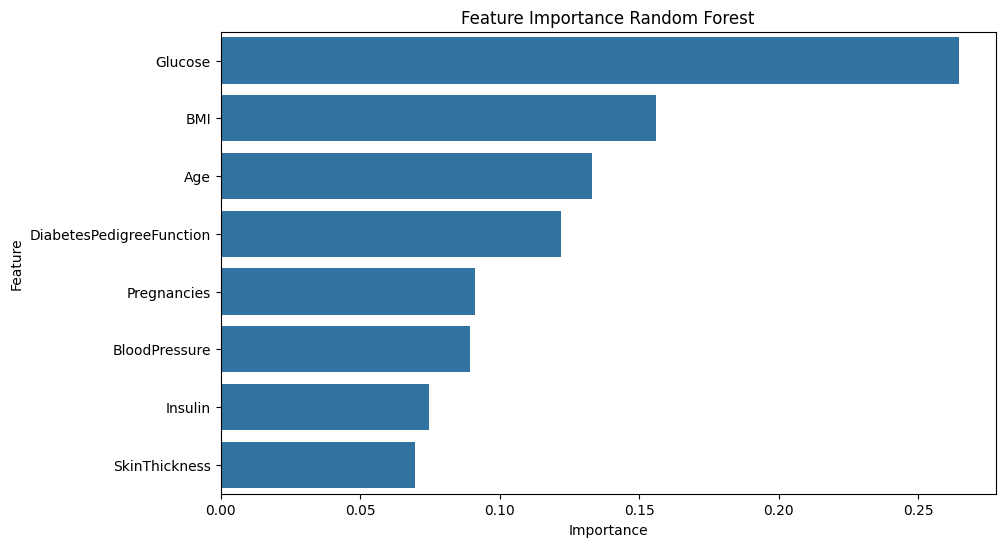

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance Random Forest")

plt.show()

In [29]:
print("""
1. Missing value berhasil dibuat dan ditangani.
2. Transformasi data berhasil dilakukan.
3. Model Random Forest berhasil dijalankan.
4. Model menghasilkan performa klasifikasi yang baik.
""")


1. Missing value berhasil dibuat dan ditangani.
2. Transformasi data berhasil dilakukan.
3. Model Random Forest berhasil dijalankan.
4. Model menghasilkan performa klasifikasi yang baik.

